In [2]:
from pathlib import Path
import os

import polars as pl
import numpy as np

import matplotlib.pyplot as plt

from IPython.display import display

from loguru import logger

In [3]:
PROJECT_ROOT = Path.cwd().parents[0]

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "jane"

TRAIN_DIR = DATA_ROOT / "train.parquet"
TEST_DIR = DATA_ROOT / "test.parquet"
LAGS_DIR = DATA_ROOT / "lags.parquet"

FEATURES_FILE = DATA_ROOT / "features.csv"
RESPONDERS_FILE = DATA_ROOT / "responders.csv"

OUTPUT_DIR = PROJECT_ROOT / "results" / "dataset"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
required = {
    "train.parquet": TRAIN_DIR,
    "test.parquet": TEST_DIR,
    "lags.parquet": LAGS_DIR,
    "features.csv": FEATURES_FILE,
    "responders.csv": RESPONDERS_FILE,
}

manifest = []

for name, path in required.items():

    exists = path.exists()

    manifest.append({
        "resource": name,
        "exists": exists,
        "path": str(path)
    })

manifest = pl.DataFrame(manifest)

display(manifest)

manifest.write_csv(
    OUTPUT_DIR / "dataset_manifest.csv"
)

resource,exists,path
str,bool,str
"""train.parquet""",true,"""D:\distribution-free-sequentia…"
"""test.parquet""",true,"""D:\distribution-free-sequentia…"
"""lags.parquet""",true,"""D:\distribution-free-sequentia…"
"""features.csv""",true,"""D:\distribution-free-sequentia…"
"""responders.csv""",true,"""D:\distribution-free-sequentia…"


In [5]:
def folder_size(folder):

    total = 0

    if folder.is_file():
        return folder.stat().st_size

    for file in folder.rglob("*"):

        if file.is_file():

            total += file.stat().st_size

    return total

In [6]:
storage = []

for name, folder in [

    ("train", TRAIN_DIR),

    ("test", TEST_DIR),

    ("lags", LAGS_DIR),

]:

    parquet_files = list(folder.rglob("*.parquet"))

    storage.append({

        "dataset": name,

        "files": len(parquet_files),

        "size_mb": folder_size(folder)/1024**2,

        "size_gb": folder_size(folder)/1024**3,

    })

storage = pl.DataFrame(storage)

display(storage)

storage.write_csv(
    OUTPUT_DIR/"storage_report.csv"
)

dataset,files,size_mb,size_gb
str,i64,f64,f64
"""train""",10,11729.911985,11.454992
"""test""",1,0.02686,0.000026
"""lags""",1,0.005486,0.000005


In [7]:
train = pl.scan_parquet(
    TRAIN_DIR/"**/*.parquet"
)

test = pl.scan_parquet(
    TEST_DIR/"**/*.parquet"
)

lags = pl.scan_parquet(
    LAGS_DIR/"**/*.parquet"
)

In [8]:
schema = train.collect_schema()

schema_df = pl.DataFrame({

    "column": schema.names(),

    "dtype": [

        str(dtype)

        for dtype in schema.dtypes()

    ]

})

display(schema_df)

schema_df.write_csv(
    OUTPUT_DIR/"schema.csv"
)

column,dtype
str,str
"""date_id""","""Int16"""
"""time_id""","""Int16"""
"""symbol_id""","""Int8"""
"""weight""","""Float32"""
"""feature_00""","""Float32"""
…,…
"""responder_4""","""Float32"""
"""responder_5""","""Float32"""
"""responder_6""","""Float32"""


In [9]:
columns = schema.names()

feature_cols = sorted(

    [

        c

        for c in columns

        if c.startswith("feature_")

    ]

)

responder_cols = sorted(

    [

        c

        for c in columns

        if c.startswith("responder_")

    ]

)

metadata_cols = [

    c

    for c in columns

    if c not in feature_cols

       and c not in responder_cols

]

classification = pl.DataFrame({

    "metadata_columns":[", ".join(metadata_cols)],

    "feature_count":[len(feature_cols)],

    "responder_count":[len(responder_cols)]

})

display(classification)

classification.write_csv(
    OUTPUT_DIR/"column_classification.csv"
)

metadata_columns,feature_count,responder_count
str,i64,i64
"""date_id, time_id, symbol_id, w…",79,9


In [10]:
overview = pl.DataFrame({

    "Metric":[

        "Rows",

        "Columns",

        "Trading Days",

        "Symbols",

        "Time Steps",

        "Feature Columns",

        "Responder Columns"

    ],

    "Value":[

        train.select(pl.len()).collect().item(),

        len(columns),

        train.select(

            pl.col("date_id").n_unique()

        ).collect().item(),

        train.select(

            pl.col("symbol_id").n_unique()

        ).collect().item(),

        train.select(

            pl.col("time_id").n_unique()

        ).collect().item(),

        len(feature_cols),

        len(responder_cols)

    ]

})

display(overview)

overview.write_csv(
    OUTPUT_DIR/"dataset_card.csv"
)

Metric,Value
str,i64
"""Rows""",47127338
"""Columns""",92
"""Trading Days""",1699
"""Symbols""",39
"""Time Steps""",968
"""Feature Columns""",79
"""Responder Columns""",9


In [11]:
from datetime import datetime

In [12]:
partition_summary = []

for partition in sorted(TRAIN_DIR.glob("partition_id=*")):

    part_name = partition.name

    parquet_files = list(partition.glob("*.parquet"))

    if len(parquet_files) == 0:
        continue

    df = pl.scan_parquet(partition / "*.parquet")

    summary = df.select(

        pl.len().alias("rows"),

        pl.col("date_id").min().alias("min_date"),

        pl.col("date_id").max().alias("max_date"),

        pl.col("symbol_id").n_unique().alias("symbols"),

        pl.col("time_id").n_unique().alias("time_steps")

    ).collect()

    partition_summary.append({

        "partition": part_name,

        "rows": summary["rows"][0],

        "min_date": summary["min_date"][0],

        "max_date": summary["max_date"][0],

        "symbols": summary["symbols"][0],

        "time_steps": summary["time_steps"][0],

        "size_mb": folder_size(partition) / 1024**2

    })

partition_summary = pl.DataFrame(partition_summary)

display(partition_summary)

partition_summary.write_csv(
    OUTPUT_DIR / "partition_summary.csv"
)

partition,rows,min_date,max_date,symbols,time_steps,size_mb
str,i64,i64,i64,i64,i64,f64
"""partition_id=0""",1944210,0,169,20,849,448.552808
"""partition_id=1""",2804247,170,339,20,849,679.066153
"""partition_id=2""",3036873,340,509,29,849,757.974182
"""partition_id=3""",4016784,510,679,29,968,1003.639508
"""partition_id=4""",5022952,680,849,33,968,1261.396297
"""partition_id=5""",5348200,850,1019,36,968,1341.922125
"""partition_id=6""",6203912,1020,1189,39,968,1555.140511
"""partition_id=7""",6335560,1190,1359,39,968,1584.836435
"""partition_id=8""",6140024,1360,1529,39,968,1533.753609


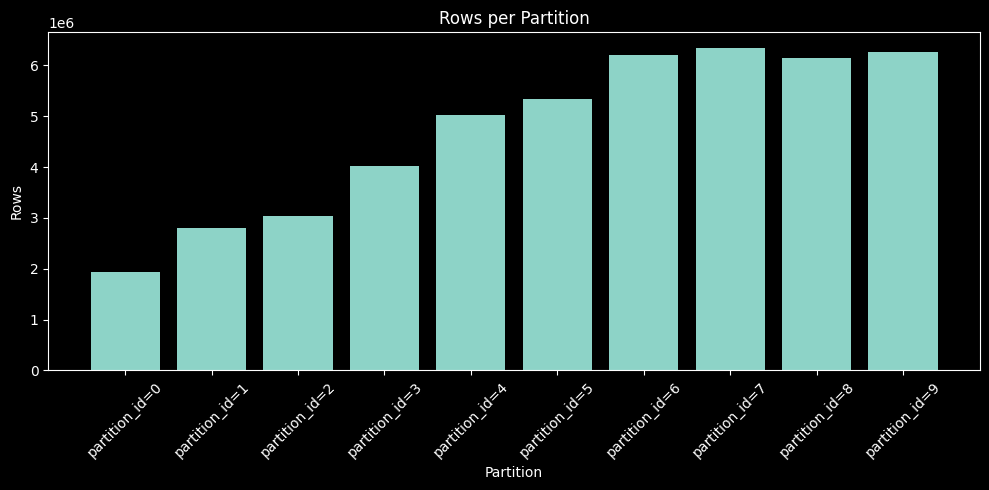

In [13]:
pdf = partition_summary.to_pandas()

plt.figure(figsize=(10,5))

plt.bar(pdf["partition"], pdf["rows"])

plt.title("Rows per Partition")

plt.xlabel("Partition")

plt.ylabel("Rows")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT /
    "results" /
    "figures" /
    "partition_row_distribution.png",
    dpi=300
)

plt.show()

In [14]:
date_summary = (

    train

    .group_by("date_id")

    .agg(

        pl.len().alias("rows"),

        pl.col("symbol_id").n_unique().alias("symbols"),

        pl.col("time_id").n_unique().alias("time_steps")

    )

    .sort("date_id")

    .collect()

)

display(date_summary.head())

date_summary.write_csv(
    OUTPUT_DIR / "date_summary.csv"
)

date_id,rows,symbols,time_steps
i16,u32,u32,u32
0,6792,8,849
1,10188,12,849
2,9339,11,849
3,10188,12,849
4,10188,12,849


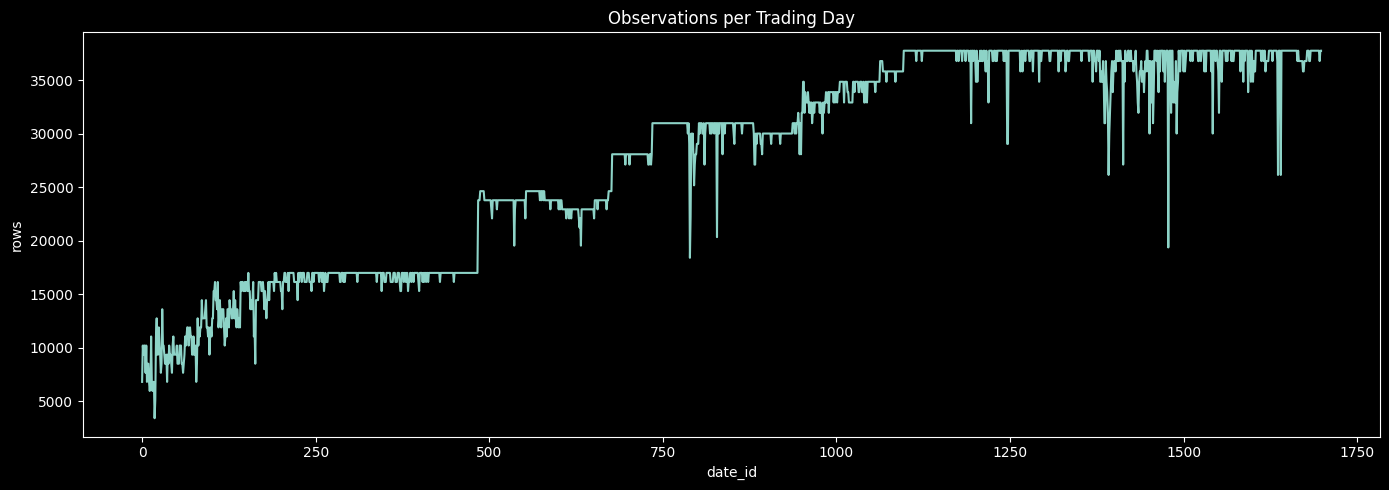

In [15]:
pdf = date_summary.to_pandas()

plt.figure(figsize=(14,5))

plt.plot(
    pdf["date_id"],
    pdf["rows"]
)

plt.title("Observations per Trading Day")

plt.xlabel("date_id")

plt.ylabel("rows")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT /
    "results" /
    "figures" /
    "observations_per_day.png",
    dpi=300
)

plt.show()

In [16]:
symbol_summary = (

    train

    .group_by("symbol_id")

    .agg(

        pl.len().alias("rows"),

        pl.col("date_id").n_unique().alias("days"),

        pl.col("time_id").n_unique().alias("time_steps")

    )

    .sort("rows", descending=True)

    .collect()

)

display(symbol_summary.head())

symbol_summary.write_csv(
    OUTPUT_DIR / "symbol_summary.csv"
)

symbol_id,rows,days,time_steps
i8,u32,u32,u32
19,1550501,1684,968
7,1546272,1680,968
1,1543979,1678,968
16,1538290,1672,968
9,1525333,1658,968


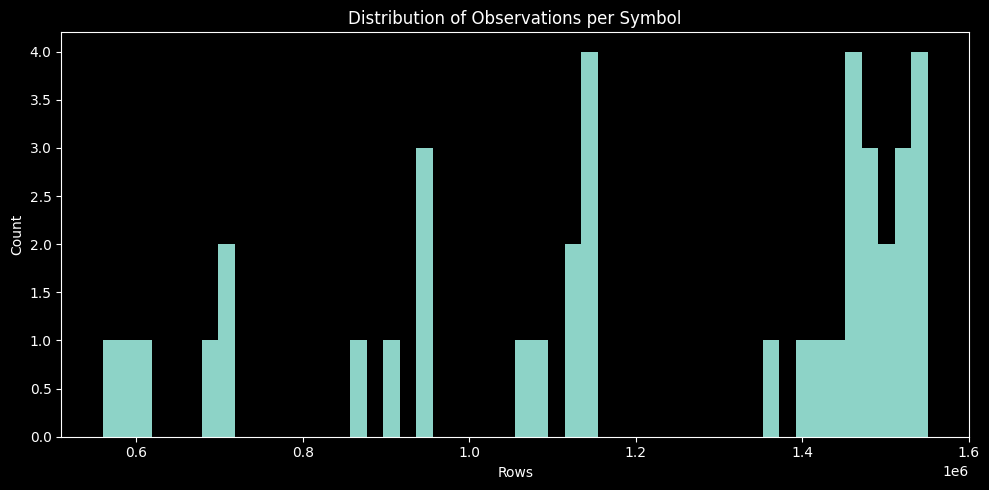

In [17]:
pdf = symbol_summary.to_pandas()

plt.figure(figsize=(10,5))

plt.hist(
    pdf["rows"],
    bins=50
)

plt.title("Distribution of Observations per Symbol")

plt.xlabel("Rows")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT /
    "results" /
    "figures" /
    "symbol_distribution.png",
    dpi=300
)

plt.show()

In [18]:
time_summary = (

    train

    .group_by("time_id")

    .agg(

        pl.len().alias("rows"),

        pl.col("symbol_id").n_unique().alias("symbols")

    )

    .sort("time_id")

    .collect()

)

display(time_summary)

time_summary.write_csv(
    OUTPUT_DIR / "time_summary.csv"
)

time_id,rows,symbols
i16,u32,u32
0,50382,39
1,50382,39
2,50382,39
3,50382,39
4,50382,39
…,…,…
963,36580,39
964,36580,39
965,36580,39


In [19]:
feature_summary = []

for col in feature_cols:

    stats = (
        train
        .select(
            pl.col(col).count().alias("count"),
            pl.col(col).null_count().alias("null_count"),
            pl.col(col).mean().alias("mean"),
            pl.col(col).std().alias("std"),
            pl.col(col).min().alias("min"),
            pl.col(col).quantile(0.25).alias("q25"),
            pl.col(col).median().alias("median"),
            pl.col(col).quantile(0.75).alias("q75"),
            pl.col(col).max().alias("max"),
            pl.col(col).n_unique().alias("unique")
        )
        .collect()
    )

    feature_summary.append({

        "feature": col,

        "count": stats["count"][0],

        "null_count": stats["null_count"][0],

        "null_pct": stats["null_count"][0] /
                    stats["count"][0] * 100,

        "mean": stats["mean"][0],

        "std": stats["std"][0],

        "min": stats["min"][0],

        "q25": stats["q25"][0],

        "median": stats["median"][0],

        "q75": stats["q75"][0],

        "max": stats["max"][0],

        "unique": stats["unique"][0]

    })

feature_summary = (
    pl.DataFrame(feature_summary)
    .sort("feature")
)

display(feature_summary)

feature_summary.write_csv(
    OUTPUT_DIR / "feature_summary.csv"
)

feature,count,null_count,null_pct,mean,std,min,q25,median,q75,max,unique
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""feature_00""",43945286,3182052,7.24094,0.573833,1.327413,-5.794129,-0.332597,0.405783,1.261608,6.477002,33358770
"""feature_01""",43945286,3182052,7.24094,0.010192,1.084941,-5.741592,-0.721098,0.007342,0.729377,6.292391,33524951
"""feature_02""",43945286,3182052,7.24094,0.573102,1.32287,-5.72601,-0.329828,0.407041,1.258622,6.490265,33334910
"""feature_03""",43945286,3182052,7.24094,0.572745,1.322849,-5.60189,-0.330473,0.406398,1.258682,6.695623,33341632
"""feature_04""",43945286,3182052,7.24094,-0.000852,1.037188,-5.79988,-0.706751,0.002276,0.703709,6.16416,33427243
…,…,…,…,…,…,…,…,…,…,…,…
"""feature_74""",46643579,483759,1.03714,-0.023103,0.958618,-6.107176,-0.348328,-0.214756,0.062082,228.661392,31287379
"""feature_75""",47068908,58430,0.124137,-0.002237,0.956047,-6.279804,-0.291265,-0.225563,-0.017734,213.313828,27229426
"""feature_76""",47068908,58430,0.124137,-0.008022,0.948959,-5.730657,-0.302702,-0.215698,-0.015261,260.911194,29136449


In [20]:
feature_missing = (

    feature_summary

    .select(
        "feature",
        "null_count",
        "null_pct"
    )

    .sort(
        "null_pct",
        descending=True
    )

)

display(feature_missing)

feature_missing.write_csv(
    OUTPUT_DIR /
    "feature_missing.csv"
)

feature,null_count,null_pct
str,i64,f64
"""feature_21""",8435985,21.803283
"""feature_26""",8435985,21.803283
"""feature_27""",8435985,21.803283
"""feature_31""",8435985,21.803283
"""feature_39""",4300649,10.041983
…,…,…
"""feature_68""",0,0.0
"""feature_69""",0,0.0
"""feature_70""",0,0.0


In [21]:
feature_variance = []

for col in feature_cols:

    variance = (

        train

        .select(

            pl.col(col).var()

        )

        .collect()

        .item()

    )

    feature_variance.append({

        "feature": col,

        "variance": variance

    })

feature_variance = (

    pl.DataFrame(feature_variance)

    .sort(
        "variance",
        descending=True
    )

)

display(feature_variance)

feature_variance.write_csv(
    OUTPUT_DIR /
    "feature_variance.csv"
)

feature,variance
str,f64
"""feature_11""",27067.835268
"""feature_09""",571.071478
"""feature_10""",9.220414
"""feature_24""",2.101426
"""feature_00""",1.762025
…,…
"""feature_40""",0.713701
"""feature_62""",0.628262
"""feature_31""",0.543731


In [22]:
constant_features = (

    feature_variance

    .filter(

        pl.col("variance") == 0

    )

)

display(constant_features)

constant_features.write_csv(
    OUTPUT_DIR /
    "constant_features.csv"
)

feature,variance
str,f64


In [23]:
responder_summary = []

for col in responder_cols:

    stats = (

        train

        .select(

            pl.col(col).mean().alias("mean"),

            pl.col(col).std().alias("std"),

            pl.col(col).min().alias("min"),

            pl.col(col).median().alias("median"),

            pl.col(col).max().alias("max"),

            pl.col(col).null_count().alias("null")

        )

        .collect()

    )

    responder_summary.append({

        "responder": col,

        "mean": stats["mean"][0],

        "std": stats["std"][0],

        "min": stats["min"][0],

        "median": stats["median"][0],

        "max": stats["max"][0],

        "null": stats["null"][0]

    })

responder_summary = pl.DataFrame(responder_summary)

display(responder_summary)

responder_summary.write_csv(
    OUTPUT_DIR /
    "responder_summary.csv"
)

responder,mean,std,min,median,max,null
str,f64,f64,f64,f64,f64,i64
"""responder_0""",-0.001545,0.591211,-5.0,-0.004543,5.0,0
"""responder_1""",-0.000866,0.587551,-5.0,-0.023831,5.0,0
"""responder_2""",-0.000142,0.599179,-5.0,-0.000862,5.0,0
"""responder_3""",-0.01638,0.819231,-5.0,-0.025754,5.0,0
"""responder_4""",-0.012442,0.87284,-5.0,-0.04469,5.0,0
"""responder_5""",-0.016624,0.734546,-5.0,-0.009662,5.0,0
"""responder_6""",-0.002141,0.889852,-5.0,-0.025566,5.0,0
"""responder_7""",0.001476,0.916042,-5.0,-0.039172,5.0,0
"""responder_8""",-0.001114,0.864412,-5.0,-0.008617,5.0,0


In [24]:
feature_range = (

    feature_summary

    .with_columns(

        (
                pl.col("max") - pl.col("min")
        ).alias("range")

    )

    .sort(
        "range",
        descending=True
    )

)

display(feature_range)

feature_range.write_csv(
    OUTPUT_DIR /
    "feature_range.csv"
)

feature,count,null_count,null_pct,mean,std,min,q25,median,q75,max,unique,range
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""feature_47""",47127251,87,0.000185,-0.010571,1.171834,-49.94656,-0.328698,0.00995,0.327563,1019.113831,37720672,1069.06039
"""feature_48""",47127338,0,0.0,-0.00172,0.859386,-311.418213,-0.188943,-0.003375,0.19183,487.60965,39941750,799.027863
"""feature_71""",47127338,0,0.0,-0.021157,0.886376,-0.825984,-0.354698,-0.239457,0.005978,735.592896,28255488,736.41888
"""feature_11""",47127338,0,0.0,170.69312,164.523054,9.0,59.0,76.0,230.0,539.0,31,530.0
"""feature_59""",47127338,0,0.0,-0.002545,0.94698,-169.922882,-0.219139,-0.003226,0.223869,256.867371,39882112,426.790253
…,…,…,…,…,…,…,…,…,…,…,…,…
"""feature_28""",47127338,0,0.0,-0.155543,1.038651,-4.063898,-0.921974,-0.203686,0.637064,2.88091,50360,6.944808
"""feature_22""",47127338,0,0.0,0.067906,0.979838,-2.602898,-0.659105,-0.090226,0.687804,4.128449,50366,6.731347
"""feature_25""",47127338,0,0.0,0.092576,1.020206,-2.178431,-0.724598,-0.092646,0.792469,4.136297,50363,6.314728


In [28]:
def metric(name: str, value) -> dict:
    return {
        "Metric": name,
        "Value": float(value)
    }


quality_report = pl.DataFrame([
    metric(
        "Total Features",
        len(feature_cols)
    ),
    metric(
        "Total Responders",
        len(responder_cols)
    ),
    metric(
        "Constant Features",
        constant_features.height
    ),
    metric(
        "Features with Missing",
        feature_missing.filter(
            pl.col("null_pct") > 0
        ).height
    ),
    metric(
        "Maximum Missing (%)",
        feature_missing["null_pct"].max()
    ),
    metric(
        "Largest Variance",
        feature_variance["variance"].max()
    ),
    metric(
        "Largest Dynamic Range",
        feature_range["range"].max()
    ),
])

display(quality_report)

quality_report.write_csv(
    OUTPUT_DIR / "dataset_quality_report.csv"
)

Metric,Value
str,f64
"""Total Features""",79.0
"""Total Responders""",9.0
"""Constant Features""",0.0
"""Features with Missing""",47.0
"""Maximum Missing (%)""",21.803283
"""Largest Variance""",27067.835268
"""Largest Dynamic Range""",1069.06039


In [ ]:
|